# Dataset for Byte Pair Encoding

In [1]:
import os
import random
from pathlib import Path

os.chdir(Path.cwd().parents[0])
print("Now in:", Path.cwd())

import pandas as pd
import numpy as np


dataPathCSV = str(Path.cwd()) + r"\data\csv" + "\\"
PlotPath = str(Path.cwd()) + r"\out\plots\bpe" + "\\"


Now in: C:\Users\stsax\OneDrive\Studium\9. Semester\Masterarbeit\Repository


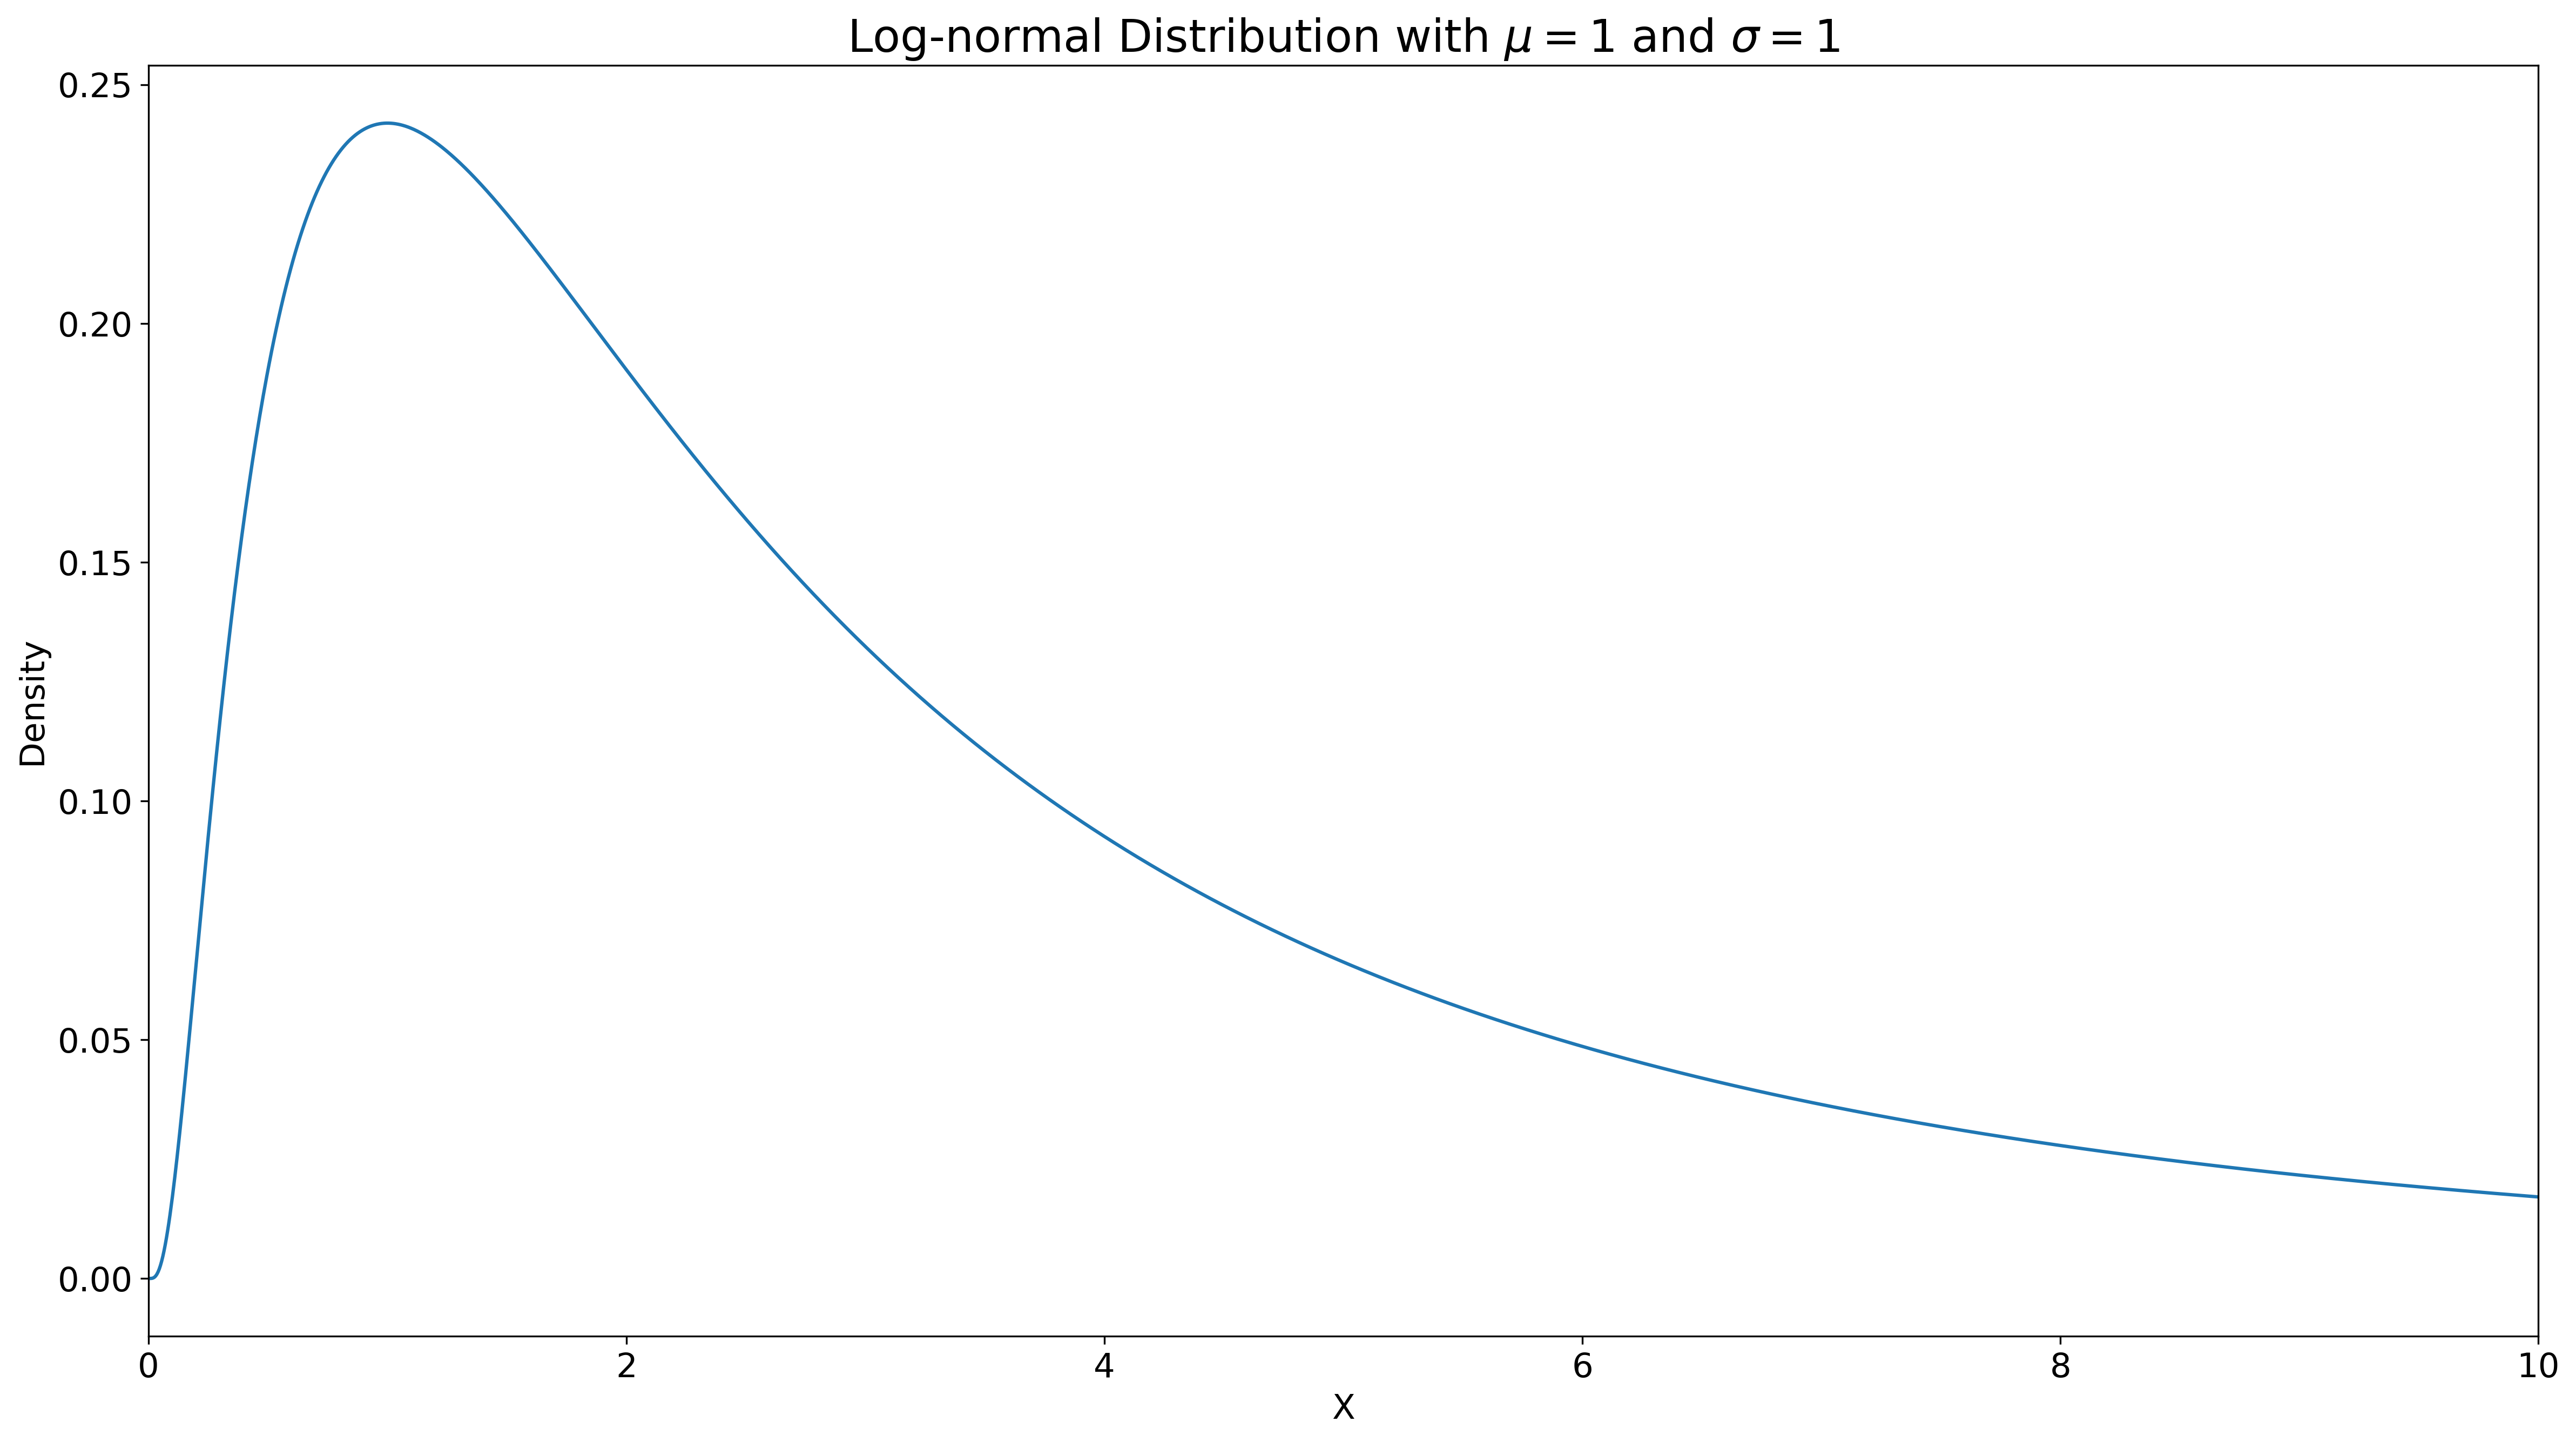

In [2]:
from plotting.src.functions import FONTSIZE_LABEL, FONTSIZE_TICKS, FONTSIZE_TITLE
import matplotlib.pyplot as plt


def pdf_log_normal(value, mu, sigma):
    return np.exp(-(np.log(value) - mu)**2 / (2 * sigma**2)) / (value * sigma * np.sqrt(2 * np.pi))

MU = 1
SIGMA = 1

x = np.linspace(1e-9, 10, num=2001)
y =  pdf_log_normal(x, MU, SIGMA)

plt.figure(figsize=(16,9), dpi = 300)
plt.plot(x, y)
plt.xticks(fontsize=FONTSIZE_TICKS)
plt.yticks(fontsize=FONTSIZE_TICKS)
plt.xlabel("X", fontsize=FONTSIZE_LABEL)
plt.ylabel("Density", fontsize=FONTSIZE_LABEL)
plt.title(r"Log-normal Distribution with $\mu = 1$ and $\sigma = 1$", fontsize=FONTSIZE_TITLE)
plt.xlim(left=0, right=10)
plt.tight_layout()
plt.savefig(PlotPath + "Log-normal Distribution.png", dpi=300)
plt.show()

In [3]:
data_synthetic = pd.read_parquet(dataPathCSV + r"\Processed Files\synthetic_samples_other_device_train.parquet")
data_synthetic['Time Delta'] = np.random.lognormal(mean=MU, sigma=SIGMA, size = data_synthetic.shape[0])
data_synthetic['Time Delta'] = (data_synthetic['Time Delta'] * 1_000_000).astype(int)

In [4]:
data_real = pd.read_parquet(dataPathCSV + r"\Processed Files\labeled_and_aggregated_data_train.parquet")

data_real = data_real.sort_values(["Label", "File", "Source", "Time"]).reset_index()
data_real['Time Delta'] = data_real.groupby(['Label', 'Source', 'File'])['Time'].diff()
data_real.dropna(inplace=True)

data_real['Time Delta'] = (data_real['Time Delta'] * 1_000_000).astype(int)

In [5]:
from data_processing.LabelLut import LABEL_OTHER_DEVICE

data_other = data_real[data_real['Label'] == LABEL_OTHER_DEVICE]
data_tracker = data_real[data_real['Label'] != LABEL_OTHER_DEVICE]

size_per_class = 10_000

data_tracker = data_tracker.groupby("Label").sample(size_per_class, random_state=0).reset_index(drop=True)

data_other = pd.concat([data_other, data_synthetic], ignore_index=True)
data_other = data_other.sample(data_tracker['Label'].nunique() * size_per_class, random_state=0).reset_index(drop=True)

In [6]:
data_bpe = pd.concat([data_other, data_tracker])
data_bpe = data_bpe[["Time Delta", "Channel", "RSSI", "Hex Data", "Label"]]

In [7]:
from concurrent.futures import ProcessPoolExecutor, as_completed
from multiprocessing import cpu_count
from data_masking.MaskLabelLut import MASK_LABEL_LUT

from data_processing.preprocessing_functions import apply_chunk_mask, chunk_df, random_state_generator

MASK_PATH = str(Path.cwd()) + r"\data_masking\mask_configs\\"
n_chunks = 1_000

dfs = []

with ProcessPoolExecutor(max_workers=cpu_count()) as executor:
    futures = [
        executor.submit(apply_chunk_mask, df, random_state, MASK_LABEL_LUT, MASK_PATH) for df, random_state in zip(chunk_df(data_bpe, n_chunks), random_state_generator(n_chunks))
    ]

    for future in as_completed(futures):
        dfs.append(future.result())

In [8]:
data_bpe = pd.concat(dfs)
data_bpe.reset_index(drop=True, inplace=True)
data_bpe.info()

<class 'pandas.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Time Delta  300000 non-null  int64 
 1   Channel     300000 non-null  int64 
 2   RSSI        300000 non-null  int64 
 3   Hex Data    300000 non-null  str   
 4   Label       300000 non-null  string
dtypes: int64(3), str(1), string(1)
memory usage: 37.2 MB


In [9]:
data_bpe['Time Delta'] = data_bpe['Time Delta'].apply(lambda x: min(x, 2**32 - 1))
data_bpe['Time Delta'] = data_bpe['Time Delta'].apply(lambda x: max(x, 0))

In [10]:
data_bpe.to_parquet(dataPathCSV + r"Processed Files\data_bpe_train.parquet",
                engine="pyarrow",
                compression="snappy",
                index=False)